<a href="https://colab.research.google.com/github/ksenia-andreeva/kan-physics-recovery/blob/main/kan_multkan.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# **Практика: Восстановление физического закона из данных**

# **Установка библиотек**

In [ ]:
!pip install git+https://github.com/KindXiaoming/pykan.git

import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from scipy.integrate import solve_ivp
from kan import KAN
from kan.utils import ex_round

torch.set_default_dtype(torch.float32)

device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"Работает на устройстве: {device}")

  Cloning https://github.com/KindXiaoming/pykan.git to /tmp/pip-req-build-g0789ey7
  Running command git clone --filter=blob:none --quiet https://github.com/KindXiaoming/pykan.git /tmp/pip-req-build-g0789ey7
  Resolved https://github.com/KindXiaoming/pykan.git to commit ecde4ec3274d3bef1ad737479cf126aed38ab530
  Preparing metadata (setup.py) ... done
  Created wheel for pykan: filename=pykan-0.2.8-py3-none-any.whl size=78235 sha256=8f8d9127cc28aee6b98336933b05f04a4ff254a4de7943034390ff053007e505
  Stored in directory: /tmp/pip-ephem-wheel-cache-rxlk3vsg/wheels/e5/c9/d6/a9b7aad8b3f7e1dde415462c7dd48df332ec616b149d51bcb8
Successfully built pykan
Работает на устройстве: cpu


# **Обучение MultKAN**

# Попытка обобщения без инженерии признаков (MultKAN с 5 исходными переменными)

**Задача:** проверить, способен ли MultKAN – вариант KAN с узлами умножения – самостоятельно восстановить закон
a=−(k/m)x−(c/m)v, располагая только исходными переменными (x, v, k, c, 1/m) без каких‑либо дополнительных физических комбинаций.

**Метод:** использована архитектура MultKAN с двумя мультипликативными нейронами ([5, [4,2], 1], grid=5, k=3). Сеть обучалась в два этапа: 800 шагов Adam, затем 500 шагов L‑BFGS с лёгкой энтропийной регуляризацией. После обучения проводилась многоэтапная обрезка и дообучение, затем символьная регрессия с библиотекой ['x'].

**Результат:** MSE на тесте составила ~2.09, предсказания оказались хаотичными и не соответствуют истинным значениям ускорения. Символьная регрессия выдала громоздкое нелинейное выражение, не имеющее физического смысла. MultKAN не смог самостоятельно сконструировать нужные произведения и деление, что подчёркивает необходимость предварительного инженеринга признаков даже при наличии мультипликативных узлов.



In [ ]:
def rhs(t, y):
    x, v = y
    a = -(k/m)*x - (c/m)*v
    return [v, a]

all_data = []

k_vals = np.linspace(1.0, 8.0, 7)
c_vals = np.linspace(0.05, 0.8, 7)
m_vals = np.linspace(0.3, 2.5, 7)

for k in k_vals:
    for c in c_vals:
        for m in m_vals:
            inv_m = 1.0 / m
            for x0 in [0, 0.5, 1.0, -0.5, -1.0]:
                for v0 in [0.0, 0.5, 1.0]:
                    sol = solve_ivp(rhs, (0, 20), y0=[x0, v0],
                                    t_eval=np.linspace(0, 10, 100))
                    x, v = sol.y
                    a = -(k/m)*x - (c/m)*v
                    for i in range(len(x)):
                        all_data.append([x[i], v[i], k, c, inv_m, a[i]])

all_data = np.array(all_data)
print(f"Всего точек: {len(all_data)}")

X = all_data[:, :5]   # x, v, k, c, 1/m
y = all_data[:, 5]    # a

# Разбиение на train/test
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

# Масштабируем только x и v (первые два столбца)
scaler = StandardScaler()
scaler.fit(X_train[:, :2])
X_train[:, :2] = scaler.transform(X_train[:, :2])
X_test[:, :2]  = scaler.transform(X_test[:, :2])

# Подвыборки для ускорения обучения
n_train = 12000
n_test  = 3000
idx_train = np.random.choice(len(X_train), n_train, replace=False)
idx_test  = np.random.choice(len(X_test),  n_test,  replace=False)

X_train_sub = X_train[idx_train]
y_train_sub = y_train[idx_train]
X_test_sub  = X_test[idx_test]
y_test_sub  = y_test[idx_test]

# Тензоры
X_train_t = torch.tensor(X_train_sub.astype(np.float32))
y_train_t = torch.tensor(y_train_sub.astype(np.float32)).reshape(-1, 1)
X_test_t  = torch.tensor(X_test_sub.astype(np.float32))
y_test_t  = torch.tensor(y_test_sub.astype(np.float32)).reshape(-1, 1)

dataset = {
    'train_input': X_train_t,
    'train_label': y_train_t,
    'test_input':  X_test_t,
    'test_label':  y_test_t
}

print(f"train: {X_train_t.shape[0]} примеров, test: {X_test_t.shape[0]} примеров")
print(f"Размерность входа: {X_train_t.shape[1]}")

Всего точек: 514500
train: 12000 примеров, test: 3000 примеров
Размерность входа: 5


checkpoint directory created: ./model
saving model version 0.0


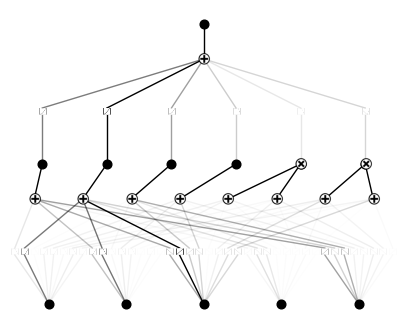

In [ ]:
model = KAN(width=[5, [4, 2], 1], grid=10, k=1, seed=42, device=device)

model(dataset['train_input'])
model.plot()

| train_loss: 9.77e-02 | test_loss: 1.32e-01 | reg: 1.88e+01 | : 100%|█| 3000/3000 [04:42<00:00, 10.


saving model version 0.1


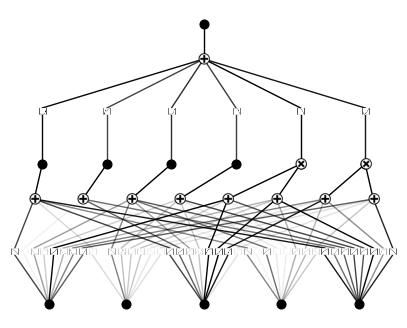

In [ ]:
model.fit(dataset, opt="Adam", steps=3000, lr=0.01, lamb=0.0, lamb_entropy=0.0)
model.plot()

| train_loss: 8.88e-02 | test_loss: 9.85e-02 | reg: 1.86e+01 | : 100%|█| 1000/1000 [01:26<00:00, 11.


saving model version 0.2


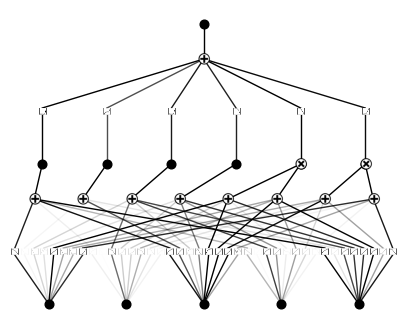

In [ ]:
model.fit(dataset, opt="Adam", steps=1000, lr=0.003, lamb=0.0, lamb_entropy=0.0)
model.plot()

In [ ]:
model.fit(dataset, opt="LBFGS", steps=500, lr=0.01, lamb=0.0, lamb_entropy=0.0)

| train_loss: 2.82e-02 | test_loss: 3.15e-02 | reg: 1.81e+01 | : 100%|█| 500/500 [15:00<00:00,  1.80


saving model version 0.3


{'train_loss': [array(0.35319278, dtype=float32),
  array(0.29844412, dtype=float32),
  array(0.24519052, dtype=float32),
  array(0.22306073, dtype=float32),
  array(0.2060824, dtype=float32),
  array(0.27930233, dtype=float32),
  array(0.22250047, dtype=float32),
  array(0.19323203, dtype=float32),
  array(0.18366306, dtype=float32),
  array(0.17718564, dtype=float32),
  array(0.23188478, dtype=float32),
  array(0.18149254, dtype=float32),
  array(0.17508972, dtype=float32),
  array(0.16770187, dtype=float32),
  array(0.16133909, dtype=float32),
  array(0.23868757, dtype=float32),
  array(0.18911691, dtype=float32),
  array(0.17516445, dtype=float32),
  array(0.16971841, dtype=float32),
  array(0.16361874, dtype=float32),
  array(0.22674896, dtype=float32),
  array(0.20624696, dtype=float32),
  array(0.18578465, dtype=float32),
  array(0.17278564, dtype=float32),
  array(0.16190317, dtype=float32),
  array(0.27260166, dtype=float32),
  array(0.214673, dtype=float32),
  array(0.1903687

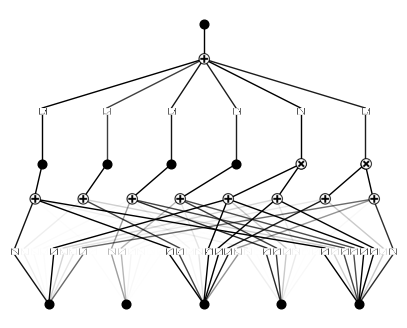

In [ ]:
model.plot()

saving model version 0.4


| train_loss: 2.61e-02 | test_loss: 2.97e-02 | reg: 2.90e+01 | : 100%|█| 100/100 [03:08<00:00,  1.88


saving model version 0.5


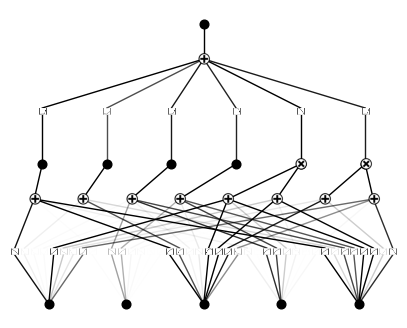

In [ ]:
model = model.prune(edge_th=1e-3)   # убирает только рёбра с весом ~0
model.fit(dataset, opt="LBFGS", steps=100, lr=0.05, update_grid=False)
model.plot()

In [ ]:
with torch.no_grad():
    pred = model(X_test_t).cpu().numpy().flatten()
mse = np.mean((pred - y_test_sub)**2)
print(f"MSE на тесте: {mse:.6f}")

print("\nПримеры предсказаний vs истина:")
indices = np.random.choice(len(X_test_sub), 5, replace=False)
for i in indices:
    x_scaled, v_scaled, k_i, c_i, inv_m_i = X_test_sub[i]
    # Обратное масштабирование
    x_orig = x_scaled * scaler.scale_[0] + scaler.mean_[0]
    v_orig = v_scaled * scaler.scale_[1] + scaler.mean_[1]

    true_a = -(k_i * inv_m_i) * x_orig - (c_i * inv_m_i) * v_orig
    pred_a = pred[i]
    print(f"  x={x_orig:.2f}, v={v_orig:.2f}, k={k_i:.2f}, c={c_i:.2f}, 1/m={inv_m_i:.3f}: "
          f"истинное a={true_a:.3f}, предсказанное a={pred_a:.3f}")

MSE на тесте: 0.000884

Примеры предсказаний vs истина:
  x=0.35, v=-0.73, k=2.17, c=0.17, 1/m=0.400: истинное a=-0.254, предсказанное a=-0.278
  x=0.02, v=0.03, k=1.00, c=0.55, 1/m=0.968: истинное a=-0.038, предсказанное a=-0.043
  x=0.00, v=0.00, k=5.67, c=0.55, 1/m=1.500: истинное a=-0.000, предсказанное a=0.015
  x=-0.16, v=0.02, k=5.67, c=0.42, 1/m=0.469: истинное a=0.412, предсказанное a=0.425
  x=0.25, v=-0.41, k=2.17, c=0.68, 1/m=0.566: истинное a=-0.149, предсказанное a=-0.162


In [ ]:
# Оцениваем ошибку отдельно для "сложных" точек (|a| > порога)
a_true = y_test_sub
a_pred = pred

threshold = 5.0
mask_large = np.abs(a_true) > threshold
mse_large = np.mean((a_pred[mask_large] - a_true[mask_large])**2)
print(f"Точек с |a| > {threshold}: {np.sum(mask_large)} из {len(a_true)}")
print(f"MSE на них: {mse_large:.4f}")

mask_small = np.abs(a_true) <= threshold
mse_small = np.mean((a_pred[mask_small] - a_true[mask_small])**2)
print(f"MSE на точках с |a| <= {threshold}: {mse_small:.6f}")

Точек с |a| > 5.0: 64 из 3000
MSE на них: 0.0131
MSE на точках с |a| <= 5.0: 0.000618


In [ ]:
lib = ['x']
model.auto_symbolic(lib=lib)
formula = ex_round(model.symbolic_formula()[0][0], 4)
print("Символьная формула KAN:", formula)

fixing (0,0,0) with x, r2=0.9656532406806946, c=1
fixing (0,0,1) with x, r2=0.8361250758171082, c=1
fixing (0,0,2) with x, r2=0.4991709291934967, c=1
fixing (0,0,3) with x, r2=0.5316194295883179, c=1
fixing (0,0,4) with x, r2=0.9969602823257446, c=1
fixing (0,0,5) with x, r2=0.7475449442863464, c=1
fixing (0,0,6) with x, r2=0.5466764569282532, c=1
fixing (0,0,7) with x, r2=0.977283775806427, c=1
fixing (0,1,0) with x, r2=0.24239066243171692, c=1
fixing (0,1,1) with 0
fixing (0,1,2) with x, r2=0.9334550499916077, c=1
fixing (0,1,3) with x, r2=0.9425604939460754, c=1
fixing (0,1,4) with x, r2=0.8477928638458252, c=1
fixing (0,1,5) with x, r2=0.7479265332221985, c=1
fixing (0,1,6) with x, r2=0.8955254554748535, c=1
fixing (0,1,7) with x, r2=0.7163863182067871, c=1
fixing (0,2,0) with x, r2=0.9083264470100403, c=1
fixing (0,2,1) with x, r2=0.8322136998176575, c=1
fixing (0,2,2) with x, r2=0.9691582322120667, c=1
fixing (0,2,3) with x, r2=0.9810395836830139, c=1
fixing (0,2,4) with x, r2=0.

/usr/local/lib/python3.12/dist-packages/sympy/core/sympify.py:475: UserWarning: Converting a tensor with requires_grad=True to a scalar may lead to unexpected behavior.
Consider using tensor.detach() first. (Triggered internally at /pytorch/torch/csrc/autograd/generated/python_variable_methods.cpp:836.)
  return sympify(float(a))


Символьная формула KAN: -0.7366*x_1 - 0.2852*x_2 + 0.7133*x_3 + 0.1966*x_4 + 1.6675*x_5 + 0.5915*(-0.0636*x_1 - 0.0034*x_2 + 0.5275*x_3 - 0.0002*x_4 + 0.1092*x_5 - 1.4157)*(0.2694*x_1 + 0.002*x_2 - 0.0684*x_3 + 0.0474*x_4 - 0.4605*x_5 + 0.7999) - 1.5055*(-0.0246*x_1 - 0.0027*x_2 + 0.3106*x_3 - 0.024*x_4 + 0.3176*x_5 - 0.4402)*(0.906*x_1 + 0.0065*x_2 + 0.2092*x_3 + 0.1637*x_4 + 0.6646*x_5 - 0.7948) - 2.4651
